In [491]:
import numpy as np
import matplotlib.pyplot as plt
from gridworld_env import get_task1_gridworld, get_task2_gridworld, get_task3_gridworld
from utils import paint_gridworld, get_grid

## A Look Around GridWorld

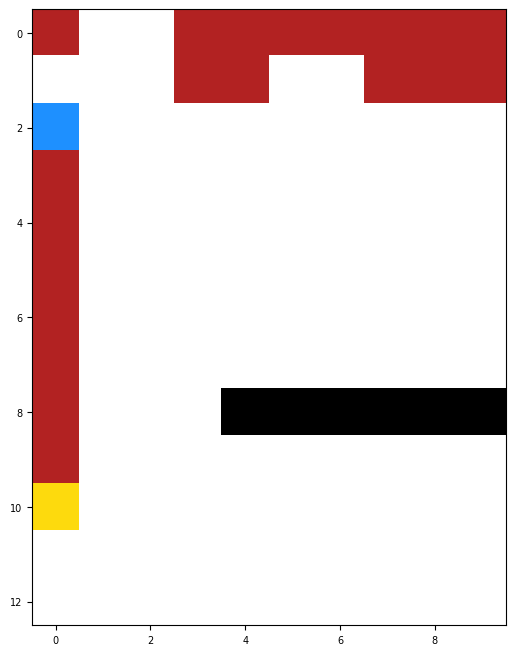

In [866]:
# Initiating the Environment. The method get_task1_gridworld
# initialises the environment for the task 1. Similarly there are methods to initialise the environment 
# for the other tasks
env1 = get_task1_gridworld()

# This is how the environment looks like
paint_gridworld(env1, figsize=(8,8), ticksize=7)



arrow_len = 0.5
def plot_directions(env, agent):
    fig, ax = plt.subplots(figsize=(8,8))
    grid = get_grid(env)
    ax.imshow(grid)
    q_values = agent.Q
    for state_x in range(env.get_gridshape()[0]):
        for state_y in range(env.get_gridshape()[1]):
            state_coords = [state_x, state_y]
            try:
                state_no = env._get_state_from_loc(state_coords)+1
                state = q_values[state_no-1]
                state_coords = [state_y, state_x]
                max_val = np.max(state)
                instances = 0
                for i in state:
                    if i == max_val:
                        instances += 1
                if instances != 1:
                    pass
                elif np.argmax(state) == 0:
                    plt.arrow(state_coords[0], state_coords[1]+(arrow_len/2), 0, -arrow_len, head_length=arrow_len/6, head_width=arrow_len/6)
                elif np.argmax(state) == 1:
                    plt.arrow(state_coords[0]-(arrow_len/2), state_coords[1], arrow_len, 0, head_length=arrow_len/6, head_width=arrow_len/6)
                elif np.argmax(state) == 2:
                    plt.arrow(state_coords[0], state_coords[1]-(arrow_len/2), 0, arrow_len, head_length=arrow_len/6, head_width=arrow_len/6)
                elif np.argmax(state) == 3:
                    plt.arrow(state_coords[0]+(arrow_len/2), state_coords[1], -arrow_len, 0, head_length=arrow_len/6, head_width=arrow_len/6)
            except:
                pass
        





## Example of running a simulation 

In [493]:
reward_lst = []

# Initialise the environment
# An arbitary gamma value is used here. You may need to change this!
env1 = get_task1_gridworld()

# Reset the environment to start from the starting location. 
# The reset() method returns the state, reward, and whether the episode is done or not
# More information can be found under the definition of the method
_, state, reward, done = env1.reset()
reward_lst.append(reward)

# While the trial is not done, i.e. the agent has not fallen into lava,
# the maximum length of the episode has not been exceeded, and the target has not been reached
while not done:
    
    # Take a step using the step() function and passing in one of the available actions [0, 1, 2, 3] 
    # corresponding to ['N', 'S', 'E', 'W']
    # More information can be found under the definition of the method
    # In this very simple example for each step we choose a random action
    _, state, reward, done = env1.step(np.random.choice(4))
    reward_lst.append(reward)

print(f'Collected rewards of an episode: {reward_lst}')

Collected rewards of an episode: [0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -10.0]


In [897]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

class Q_agent():
# The solve method should take the n_episodes and env as a parameter, 
# but otherwise you can modify the definition of this method
  def solve(self, env, policy='EPSILON', n_episodes=500, gamma=0.1, alpha=0.1, epsilon=0.1, tau=2.0, first_hidden_size=10, second_hidden_size=10):
    """
    Solve a given GridWorld environment using Q-learning
    input: env {GridWorld object} -- GridWorld to solve
    output:
      - policy {np.array} -- Optimal policy found to solve the given GridWorld environment
      - total_rewards {list of float} -- Corresponding list of successive total non-discounted sum of reward for each trial
      - total_steps {list of float} -- Corresponding list of successive total non-discounted sum of steps for each trial
    """
    current_loc = env._starting_loc
    self.states = env.get_state_size()
    self.actions = env.get_action_size()
    self.first_hidden_size = first_hidden_size
    self.second_hidden_size = second_hidden_size
    shape = env.get_gridshape()
    self.Q = np.zeros((self.states, self.actions))
    #self.W1 = np.random.randn(self.states, self.first_hidden_size) * 0.01
    #self.b1 = np.zeros(self.first_hidden_size)
    #self.W2 = np.random.randn(self.first_hidden_size, self.second_hidden_size) * 0.01
    #self.b2 = np.zeros(self.second_hidden_size)
    #self.W3 = np.random.rand(self.second_hidden_size, self.actions) * 0.01
    #self.b3 = np.zeros(self.actions)
    self._alpha = alpha#Learning Rate
    self._epsilon = epsilon#Explore Rate
    self._gamma = gamma#Discount
    self.tau = tau
    total_steps = []
    policy_lst = []
    total_rewards = []

    for e in range(n_episodes):
      _, state, reward, done = env.reset()
      current_total_steps = 0
      current_policy = [state]
      rewards = []
      rewards.append(reward)
      # While the trial is not done, i.e. the agent has not fallen into lava,
      # the maximum length of the episode has not been exceeded, and the target has not been reached
      while not done:
        # Take a step using the step() function and passing in one of the available actions [0, 1, 2, 3] 
        # corresponding to ['N', 'S', 'E', 'W']
        # More information can be found under the definition of the method
        # In this very simple example for each step we choose a random action
        if policy == 'EPSILON':
          action = self.epsilon_greedy_policy(state)
        elif policy == 'SOFTMAX':
          action = self.softmax_policy(state)
        #action = self.softmax_policy(state)
        _, next_state, reward, done = env.step(action)
        self.update_Q(state, action, next_state, reward)
        state = next_state
        rewards.append(reward)
        current_policy.append(state)
        current_total_steps += 1
      
      total_rewards.append(np.average(rewards))
      total_steps.append(current_total_steps)
      policy_lst.append(current_policy)

    index_of_best = np.argmax(total_rewards)
    best_path = policy_lst[index_of_best]
    best_reward = total_rewards[index_of_best]
    final_path = policy_lst[len(policy_lst)-1]
    best_path = [best_path, best_reward]

    # You may use these outputs to plot graphs
    #print(f"Q VALUES: {self.Q}")
    return best_path, final_path, total_rewards, total_steps

  def update_Q(self, state, action, next_state, reward):
    self.Q[state, action] += self._alpha * (reward + self._gamma*np.max(self.Q[next_state]) - self.Q[state, action])

  def epsilon_greedy_policy(self, state):
    #Determine optimal action(s)
    max_value = np.max(self.Q[state])
    optimal_actions = []
    for action in range(self.actions):
      if self.Q[state, action] == max_value:
        optimal_actions.append(action)
    #Determine whether the agent follows the optimal action or chooses to explore
    if np.random.rand() < self._epsilon:
      return np.random.choice(4)
    else:
      action = np.random.choice(optimal_actions)
      return action
    
  def softmax_policy(self, state):
    #Determine optimal action(s)
    q = self.Q[state]
    p = np.zeros(4, dtype=np.float64)
    for a in range(self.actions):
      n = np.e**(q[a]/self.tau)
      d = 0
      for b in range(self.actions):
        d +=  np.e**(q[b]/self.tau)
      actionProb = n/d
      #np.append(p, [actionProb])
      p[a] = actionProb
    prob = np.random.uniform(0.0, np.sum(p))
    actionProb = 0
    for action, a in enumerate(p):
      actionProb += a
      if prob < actionProb:
        return action
    return np.random.choice(4)

In [898]:
class SARSA_agent():
  # The solve method should take the n_episodes and env as a parameter, 
  # but otherwise you can modify the definition of this method
  def solve(self, env, policy='EPSILON', n_episodes=500, 
             # Extra parameters:
            gamma=0.1, alpha=0.1, epsilon=0.1, tau=2.0):
    """
    Solve a given GridWorld environment using SARSA
    input: env {GridWorld object} -- GridWorld to solve
    output:
      - policy {np.array} -- Optimal policy found to solve the given GridWorld environment
      - total_rewards {list of float} -- Corresponding list of successive total non-discounted sum of reward for each trial
      - total_steps {list of float} -- Corresponding list of successive total non-discounted sum of steps for each trial
    """

    # Initialise your variables
    self.states = env.get_state_size()
    self.actions = env.get_action_size()
    self._alpha = alpha#Learning rate
    self._gamma = gamma#Discount
    self._epsilon = epsilon#Explore rate
    self.tau = tau
    self.Q = np.zeros((self.states, self.actions))
    total_steps = []
    policy_lst = []
    total_rewards = []

    ####
    # Add your code here
    # WARNING: this agent only has access to env.reset() and env.step()
    # You should not use env.get_absorbing() to compute any value
    ####

    for e in range(n_episodes):
      _, state, reward, done = env.reset()
      current_total_steps = 0
      current_policy = [state]
      rewards = []
      rewards.append(reward)

      if policy == 'EPSILON':
        action = self.epsilon_greedy_policy(state)
      elif policy == 'SOFTMAX':
        action = self.softmax_policy(state)

      while not done:
        _, next_state, reward, done = env.step(action)
        #next_action = self.epsilon_greedy_policy(next_state)
        if policy == 'EPSILON':
          next_action = self.epsilon_greedy_policy(next_state)
        elif policy == 'SOFTMAX':
          next_action = self.softmax_policy(next_state)
        self.update_Q(state, action, next_state, next_action, reward)
        state = next_state
        action = next_action
        rewards.append(reward)
        current_policy.append(state)
        current_total_steps += 1
      
      total_rewards.append(np.average(rewards))
      total_steps.append(current_total_steps)
      policy_lst.append(current_policy)

    index_of_best = np.argmax(total_rewards)
    best_path = policy_lst[index_of_best]
    best_reward = total_rewards[index_of_best]
    best_path = [best_path, best_reward]
    final_path = policy_lst[len(policy_lst)-1]
    
    # You may use these outputs to plot graphs
    return best_path, final_path, total_rewards, total_steps

  def update_Q(self, state, action, next_state, next_action, reward):
    #Q(s, a) ← Q(s, a) + η * [r + γ * Q(s', a') - Q(s, a)] == SARSA
    self.Q[state, action] += self._alpha * (reward + self._gamma*self.Q[next_state, next_action] - self.Q[state, action])

  def epsilon_greedy_policy(self, state):
    #Determine optimal action(s)
    max_value = np.max(self.Q[state])
    optimal_actions = []
    for action in range(self.actions):
      if self.Q[state, action] == max_value:
        optimal_actions.append(action)
    #Determine whether the agent follows the optimal action or chooses to explore
    if np.random.rand() < self._epsilon:
      return np.random.choice(4)
    else:
      action = np.random.choice(optimal_actions)
      return action
    
  def softmax_policy(self, state):
    #Determine optimal action(s)
    q = self.Q[state]
    p = np.zeros(4, dtype=np.float64)
    for a in range(self.actions):
      n = np.e**(q[a]/self.tau)
      d = 0
      for b in range(self.actions):
        d +=  np.e**(q[b]/self.tau)
      actionProb = n/d
      #np.append(p, [actionProb])
      p[a] = actionProb
    prob = np.random.uniform(0.0, np.sum(p))
    actionProb = 0
    for action, a in enumerate(p):
      actionProb += a
      if prob < actionProb:
        return action
    return np.random.choice(4)

# Task 1 - Single Target, Deterministic Rewards:

In [927]:
# Example of Hyperparameters
# This is just an example, you can add to this depending on which method you utilise

no_runs_1 = 50
no_episodes_1 = 1500

s_gamma_1 = 0.58#0.95 #Discount
s_alpha_1 = 0.27#0.09 #Learning Rate
s_epsilon_1 = 0.025 #Explore Rate
s_tau_1 = 1.5

q_gamma_1 = 0.65#0.92
q_alpha_1 = 0.175#0.06
q_epsilon_1 = 0.025
q_tau_1 = 1.5
q_first_hidden_size_1 = 10
q_second_hidden_size_1 = 10

In [497]:
# This should be the definition of the gridworld for task 1. DO NOT CHANGE THIS
env1 = get_task1_gridworld()

STRATEGY: [(10, 0), (10, 1), (9, 1), (8, 1), (8, 2), (7, 2), (6, 2), (5, 2), (5, 1), (4, 1), (3, 1), (2, 1), (2, 0)]
Best Length: 13
Final Length: 15
TOTAL REWARD: [-0.10638297872340426, -5.0, -0.29411764705882354, 0.0, -0.37037037037037035, -0.4166666666666667, -0.3225806451612903, -0.03289473684210526, -0.05235602094240838, -0.032467532467532464, -0.12048192771084337, -0.08771929824561403, -0.06802721088435375, -0.023310023310023312, -0.058823529411764705, -0.08620689655172414, 0.0, 0.0, 1.8115942028985508, -0.021321961620469083, 0.0, 0.0, 0.0, 0.0, -0.07462686567164178, 1.5923566878980893, 0.0, 3.2051282051282053, 0.0, 0.0, -0.2127659574468085, 0.0, 0.0, -0.038910505836575876, 1.838235294117647, 2.0161290322580645, 0.0, 3.8461538461538463, 0.0, 1.179245283018868, -0.07042253521126761, 4.854368932038835, 0.0, -0.04132231404958678, 6.666666666666667, 0.0, 0.0, 38.46153846153846, 7.462686567164179, 21.73913043478261, -0.03558718861209965, 15.625, 19.23076923076923, 1.5105740181268883, 

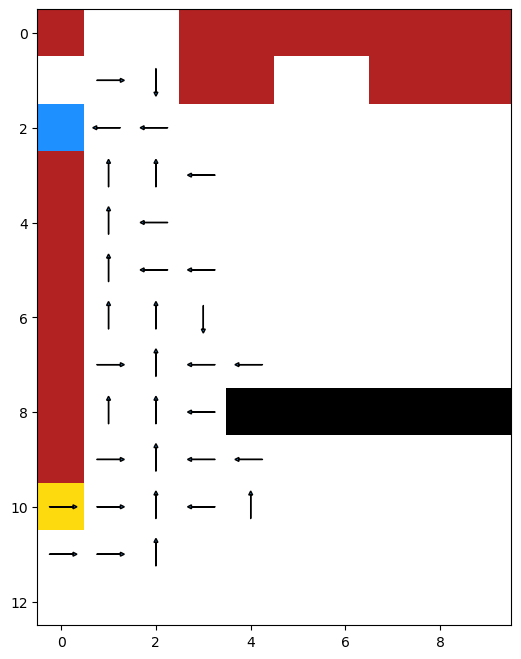

In [918]:
# Example of running SARSA
agent = SARSA_agent()

best_paths = []
best_path, final_path, sarsa_average_rewards_1, s_average_steps_1 = agent.solve(env1, gamma=s_gamma_1, alpha=s_alpha_1, epsilon=s_epsilon_1, tau=s_tau_1, n_episodes=no_episodes_1)
best_paths.append(best_path)

for run in range(no_runs_1-1):   
    best_path, final_path, sarsa_rewards_1, sarsa_total_steps_1 = agent.solve(env1, gamma=s_gamma_1, alpha=s_alpha_1, epsilon=s_epsilon_1, tau=s_tau_1, n_episodes=no_episodes_1)
    best_paths.append(best_path)
    for i in range(len(s_average_steps_1)):
        s_average_steps_1[i] += sarsa_total_steps_1[i]
        sarsa_average_rewards_1[i] += sarsa_rewards_1[i]
for i in range(len(s_average_steps_1)):
    s_average_steps_1[i] /= no_runs_1
for i in range(len(sarsa_rewards_1)):
    sarsa_rewards_1[i] /= no_runs_1

for path in best_paths:
    if path[1] > best_path[1]:
        best_path = path
best_path = best_path[0]

loc_best = []
for i in range(len(best_path)):
    loc_best.append(env1.get_loc_from_state(best_path[i]))
loc_final = []
for i in range(len(final_path)):
    loc_final.append(env1.get_loc_from_state(final_path[i]))

print(f"STRATEGY: {loc_best}")
print(f"Best Length: {len(loc_best)}")
print(f"Final Length: {len(loc_final)}")
print(f"TOTAL REWARD: {sarsa_average_rewards_1}")
print(f"TOTAL STEPS: {s_average_steps_1}")

plot_directions(env1, agent)

STRATEGY: [(10, 0), (10, 1), (9, 1), (8, 1), (8, 2), (7, 2), (6, 2), (5, 2), (4, 2), (4, 1), (3, 1), (2, 1), (2, 0)]
Best Length: 13
Final Length: 15
TOTAL REWARD: [-0.5, -0.15873015873015872, -3.3333333333333335, -0.4166666666666667, 0.0, 0.0, -0.02197802197802198, -0.10309278350515463, -0.046948356807511735, -0.0425531914893617, -0.07246376811594203, -0.2857142857142857, -0.07575757575757576, 1.838235294117647, -0.12345679012345678, 0.0, -0.030395136778115502, 0.0, 2.4630541871921183, 1.8518518518518519, -0.07246376811594203, 0.0, 1.3297872340425532, 4.032258064516129, -0.4166666666666667, 0.0, 1.1415525114155252, 0.0, 1.4450867052023122, 4.716981132075472, 1.8518518518518519, 8.620689655172415, 1.5015015015015014, 9.615384615384615, 27.77777777777778, 11.627906976744185, 26.31578947368421, 10.869565217391305, 15.151515151515152, 29.41176470588235, 22.727272727272727, 33.333333333333336, 33.333333333333336, 33.333333333333336, 33.333333333333336, 33.333333333333336, 33.33333333333333

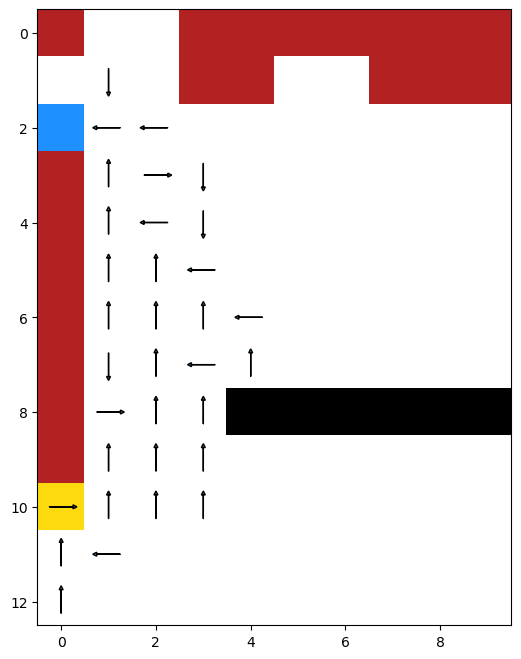

In [926]:
# Example of running Q-Learning
agent = Q_agent()
best_paths = []
best_path, final_path, q_learning_average_rewards_1, q_average_steps_1 = agent.solve(env1, gamma=q_gamma_1, alpha=q_alpha_1, epsilon=q_epsilon_1, tau=q_tau_1, n_episodes=no_episodes_1, first_hidden_size=q_first_hidden_size_1)
best_paths.append(best_path)

for run in range(no_runs_1-1):   
    best_path, final_path, q_learning_rewards_1, q_total_steps_1 = agent.solve(env1, gamma=q_gamma_1, alpha=q_alpha_1, epsilon=q_epsilon_1, tau=q_tau_1, n_episodes=no_episodes_1, first_hidden_size=q_first_hidden_size_1)
    best_paths.append(best_path)
    for i in range(len(q_average_steps_1)):
        q_average_steps_1[i] += q_total_steps_1[i]
        q_learning_average_rewards_1[i] += q_learning_rewards_1[i]

for i in range(len(q_average_steps_1)):
    q_average_steps_1[i] /= no_runs_1
for i in range(len(q_learning_rewards_1)):
    q_learning_rewards_1[i] /= no_runs_1

for path in best_paths:
    if path[1] > best_path[1]:
        best_path = path
best_path = best_path[0]

loc_best = []
for i in range(len(best_path)):
    loc_best.append(env1.get_loc_from_state(best_path[i]))
loc_final = []
for i in range(len(final_path)):
    loc_final.append(env1.get_loc_from_state(final_path[i]))

print(f"STRATEGY: {loc_best}")
print(f"Best Length: {len(loc_best)}")
print(f"Final Length: {len(loc_final)}")
print(f"TOTAL REWARD: {q_learning_average_rewards_1}")
print(f"TOTAL STEPS: {q_average_steps_1}")

plot_directions(env1, agent)

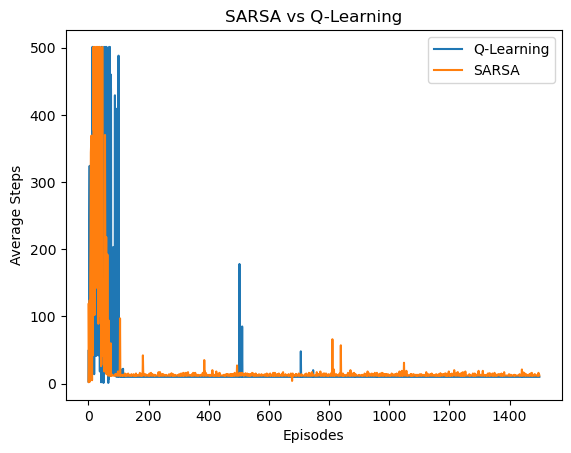

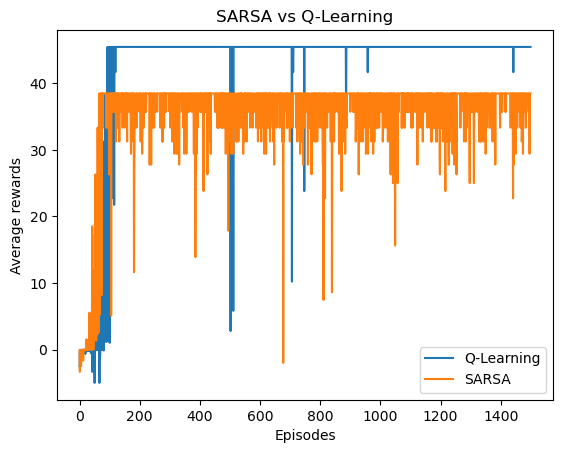

In [732]:
# Do your plots below! Include any new function definitions in this jupyter notebook!
sarsa_average = np.average(s_average_steps_1)
q_average = np.average(q_average_steps_1)
if sarsa_average > q_average:
    plt.plot(np.mean(np.array(s_average_steps_1).reshape(-1, 1), axis=1), label='SARSA')
    plt.plot(np.mean(np.array(q_average_steps_1).reshape(-1, 1), axis=1), label='Q-Learning')
else:
    plt.plot(np.mean(np.array(q_average_steps_1).reshape(-1, 1), axis=1), label='Q-Learning')
    plt.plot(np.mean(np.array(s_average_steps_1).reshape(-1, 1), axis=1), label='SARSA')
plt.xlabel('Episodes')
plt.ylabel('Average Steps')
plt.legend()
plt.title('SARSA vs Q-Learning')
plt.show()

if sarsa_average > q_average:
    plt.plot(np.mean(np.array(sarsa_average_rewards_1).reshape(-1, 1), axis=1), label='SARSA')
    plt.plot(np.mean(np.array(q_learning_average_rewards_1).reshape(-1, 1), axis=1), label='Q-Learning')
else:
    plt.plot(np.mean(np.array(q_learning_average_rewards_1).reshape(-1, 1), axis=1), label='Q-Learning')
    plt.plot(np.mean(np.array(sarsa_average_rewards_1).reshape(-1, 1), axis=1), label='SARSA')
plt.xlabel('Episodes')
plt.ylabel('Average rewards')
plt.legend()
plt.title('SARSA vs Q-Learning')
plt.show()


# Task 2 - Dual Targets with Stochastic Rewards

In [856]:
# This should be the definition of the gridworld for task 1. DO NOT CHANGE THIS
env2 = get_task2_gridworld()
no_runs_2 = 1


STRATEGY: [(10, 0), (10, 1), (9, 1), (8, 1), (7, 1), (6, 1), (5, 1), (4, 1), (3, 1), (2, 1), (2, 0)]
Best Length: 11
Final Length: 11
TOTAL REWARD: [-0.47619047619047616, -0.10204081632653061, -3.3333333333333335, -0.043668122270742356, 2.0673366818241123, -0.4166666666666667, -0.7142857142857143, -0.16666666666666666, -0.25, -0.03759398496240601, 0.9682513993104417, -0.078125, -0.025974025974025976, -0.625, 4.329727992794725, -0.14285714285714285, -0.07936507936507936, 0.0, 2.717526478531636, -3.3333333333333335, -0.028328611898016998, 0.8971112632447054, -0.8333333333333334, 0.6376934625935704, 0.7114982508243177, -0.02824858757062147, 0.6796421327709126, -0.02564102564102564, 4.45411314633447, 4.0338796305247, 5.436569864634978, -0.058823529411764705, -0.136986301369863, 14.50938317281951, 0.0, 1.0485473240349685, 1.7606502060944735, 2.6284672290525966, 5.8393282185705475, 5.842312453681696, 0.0, -0.03597122302158273, 0.685243067307246, 7.105979385264888, -0.03717472118959108, 2.121

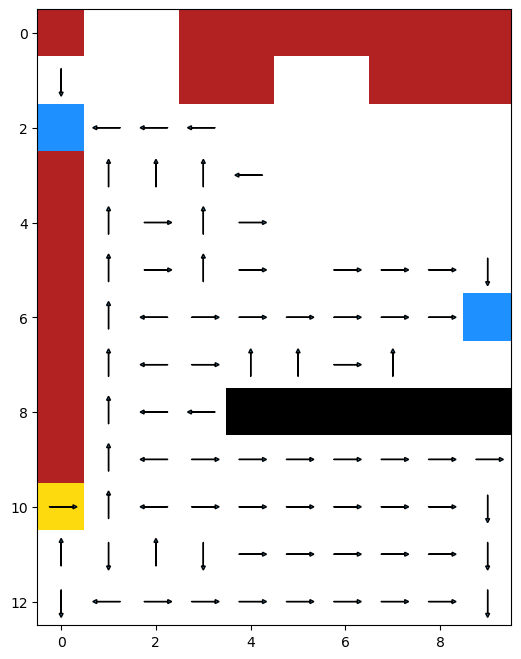

In [956]:
# Example of running SARSA
agent = SARSA_agent()

s_gamma_2 = 0.77 #Discount
s_alpha_2 = 0.2 #Learning Rate
s_epsilon_2 = 0.01 #Explore Rate
s_tau_2 = 1.2 #Softmax temperature
s_n_episodes_2 = 2500

best_paths = []
best_path, final_path, sarsa_average_rewards_2, s_average_steps_2 = agent.solve(env2, policy='SOFTMAX', gamma=s_gamma_2, alpha=s_alpha_2, epsilon=s_epsilon_2, tau=s_tau_2, n_episodes=s_n_episodes_2)
best_paths.append(best_path)

for run in range(no_runs_2-1): 
    best_path, final_path, sarsa_rewards_2, sarsa_total_steps_2 = agent.solve(env2, policy='SOFTMAX', gamma=s_gamma_2, alpha=s_alpha_2, epsilon=s_epsilon_2, tau=s_tau_2, n_episodes=s_n_episodes_2)
    best_paths.append(best_path)
    for i in range(len(s_average_steps_2)):
        s_average_steps_2[i] += sarsa_total_steps_2[i]
        sarsa_average_rewards_2[i] += sarsa_rewards_2[i]

for i in range(len(s_average_steps_2)):
    s_average_steps_2[i] /= no_runs_2
for i in range(len(sarsa_average_rewards_2)):
    sarsa_average_rewards_2[i] /= no_runs_2

for path in best_paths:
    if path[1] > best_path[1]:
        best_path = path
best_path = best_path[0]

loc_best = []
for i in range(len(best_path)):
    loc_best.append(env2.get_loc_from_state(best_path[i]))
loc_final = []
for i in range(len(final_path)):
    loc_final.append(env2.get_loc_from_state(final_path[i]))

print(f"STRATEGY: {loc_best}")
print(f"Best Length: {len(loc_best)}")
print(f"Final Length: {len(loc_final)}")
print(f"TOTAL REWARD: {sarsa_rewards_2}")
print(f"TOTAL STEPS: {sarsa_total_steps_2}")

plot_directions(env2, agent)

STRATEGY: [(10, 0), (10, 1), (9, 1), (8, 1), (7, 1), (6, 1), (5, 1), (4, 1), (3, 1), (2, 1), (2, 0)]
Best Length: 11
Final Length: 11
AVERAGE REWARD: [5.19743386901753, -1.6666666666666667, -5.0, -0.625, -0.14084507042253522, -0.053475935828877004, 0.0, -0.10526315789473684, -0.5882352941176471, -1.6666666666666667, 0.0, -0.07462686567164178, -0.06756756756756757, -0.026525198938992044, 3.750408444976614, -3.3333333333333335, -0.10101010101010101, 0.0, -0.2222222222222222, -1.6666666666666667, -1.25, 4.086127438204126, -0.027247956403269755, -0.35714285714285715, 6.230492782360186, 5.279795328828502, -0.023474178403755867, 20.30175758123118, 2.2169120981791712, 11.179642362476992, 0.0, 4.130727138695945, 5.91032373275876, -0.05649717514124294, 5.527632837453838, -0.022727272727272728, -0.06134969325153374, -0.8333333333333334, -0.07936507936507936, 4.618095428288891, 7.768735160822156, -0.37037037037037035, 11.770615639083468, -0.02197802197802198, 12.514757278797296, 2.473424168379925

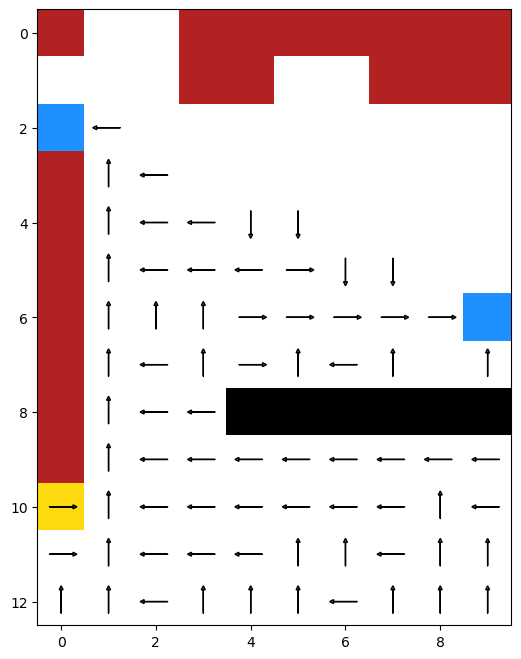

In [976]:
# Example of running Q-Learning
q_gamma_2 = 0.64#0.85 #Discount
q_alpha_2 = 0.15#0.1 #Learning Rate
q_epsilon_2 = 0.05 #Explore Rate
q_tau_2 = 1.25
q_n_episodes_2 = 2500

agent = Q_agent()
best_paths = []
best_path, final_path, q_average_rewards_2, q_average_steps_2 = agent.solve(env2, policy='SOFTMAX', gamma=q_gamma_2, alpha=q_alpha_2, epsilon=q_epsilon_2, tau=q_tau_2, n_episodes=q_n_episodes_2)
best_paths.append(best_path)

for run in range(no_runs_2-1): 
    best_path, final_path, q_rewards_2, q_total_steps_2 = agent.solve(env2, policy='SOFTMAX', gamma=s_gamma_2, alpha=s_alpha_2, epsilon=s_epsilon_2, tau=q_tau_2, n_episodes=s_n_episodes_2)
    best_paths.append(best_path)
    for i in range(len(q_average_steps_2)):
        q_average_steps_2[i] += q_total_steps_2[i]
        q_average_rewards_2[i] += q_rewards_2[i]
        
for i in range(len(q_average_steps_2)):
    q_average_steps_2[i] /= no_runs_2
for i in range(len(q_average_rewards_2)):
    q_average_rewards_2[i] /= no_runs_2

for path in best_paths:
    if path[1] > best_path[1]:
        best_path = path
best_path = best_path[0]

loc_best = []
for i in range(len(best_path)):
    loc_best.append(env2.get_loc_from_state(best_path[i]))
loc_final = []
for i in range(len(final_path)):
    loc_final.append(env2.get_loc_from_state(final_path[i]))

print(f"STRATEGY: {loc_best}")
print(f"Best Length: {len(loc_best)}")
print(f"Final Length: {len(loc_final)}")
print(f"AVERAGE REWARD: {q_average_rewards_2}")
print(f"AVERAGE STEPS: {q_average_steps_2}")

plot_directions(env2, agent)

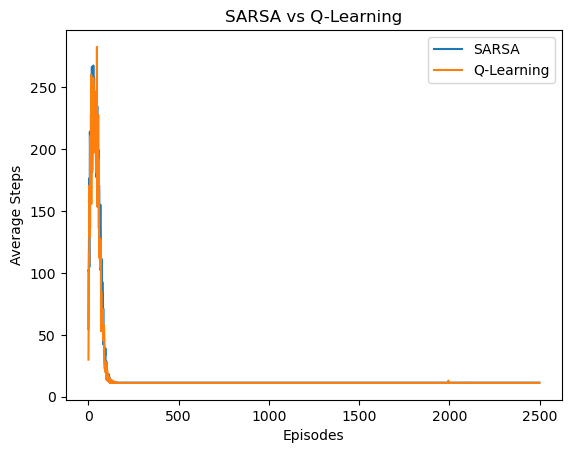

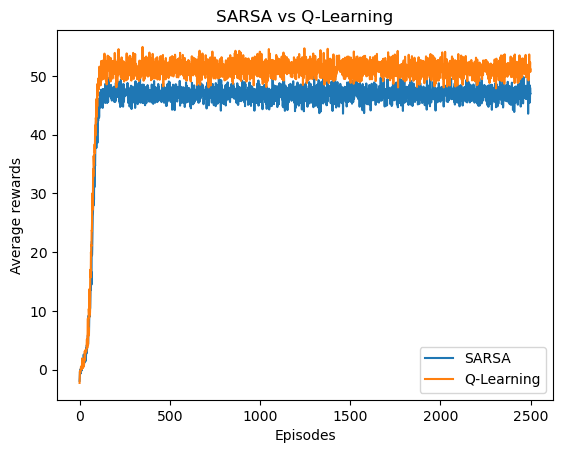

In [656]:
# Do your plots below! Include any new function definitions in this jupyter notebook!

sarsa_average = np.average(s_average_steps_2)
q_average = np.average(q_average_steps_2)
if sarsa_average > q_average:
    plt.plot(np.mean(np.array(s_average_steps_2).reshape(-1, 1), axis=1), label='SARSA')
    plt.plot(np.mean(np.array(q_average_steps_2).reshape(-1, 1), axis=1), label='Q-Learning')
else:
    plt.plot(np.mean(np.array(q_average_steps_2).reshape(-1, 1), axis=1), label='Q-Learning')
    plt.plot(np.mean(np.array(s_average_steps_2).reshape(-1, 1), axis=1), label='SARSA')
plt.xlabel('Episodes')
plt.ylabel('Average Steps')
plt.legend()
plt.title('SARSA vs Q-Learning')
plt.show()

if sarsa_average > q_average:
    plt.plot(np.mean(np.array(sarsa_average_rewards_2).reshape(-1, 1), axis=1), label='SARSA')
    plt.plot(np.mean(np.array(q_average_rewards_2).reshape(-1, 1), axis=1), label='Q-Learning')
else:
    plt.plot(np.mean(np.array(q_average_rewards_2).reshape(-1, 1), axis=1), label='Q-Learning')
    plt.plot(np.mean(np.array(sarsa_average_rewards_2).reshape(-1, 1), axis=1), label='SARSA')
plt.xlabel('Episodes')
plt.ylabel('Average rewards')
plt.legend()
plt.title('SARSA vs Q-Learning')
plt.show()

# Task 3 - Stochastic Transitions and Rewards

In [1063]:
# This should be the definition of the gridworld for task 1. DO NOT CHANGE THIS
env3 = get_task3_gridworld()
no_episodes_3 = 5000
no_runs_3 = 100

STRATEGY: [(10, 0), (10, 1), (9, 1), (8, 1), (7, 1), (6, 1), (5, 1), (4, 1), (3, 1), (2, 1), (2, 0)]
Best Length: 11
Final Length: 17
TOTAL REWARD: [-1.8367217638649245, -2.015875006618249, -1.486999559041171, -1.8372034699663222, -1.1691934479129047, -1.5953096424885131, -1.3070391537862711, -0.900425625414439, -1.2574959909663772, -1.1360071352632475, -0.8571533841209447, -1.463935774237414, -1.0766372867777312, -0.8813345698440328, -1.035847857407591, -1.005229970624923, -1.232027834089297, -0.7547325865820689, -1.0181060735931922, -1.0586037309523766, -0.7543130622339059, -1.1350178448252422, -0.9736739094754189, -0.4742373191302541, -1.1046638649721374, -0.7880270143684593, -1.004268151195605, -0.9399926211165822, -0.6512463000815135, -0.5158724233077122, -0.6773657395079122, -0.6982410489866053, -0.9204463961767236, -0.5595495222809397, -0.6731856474373845, -0.4014724153992587, -0.9732838227545009, -0.4713124237518268, -0.7569534470739676, -0.7252076834993433, -0.8806263823697992

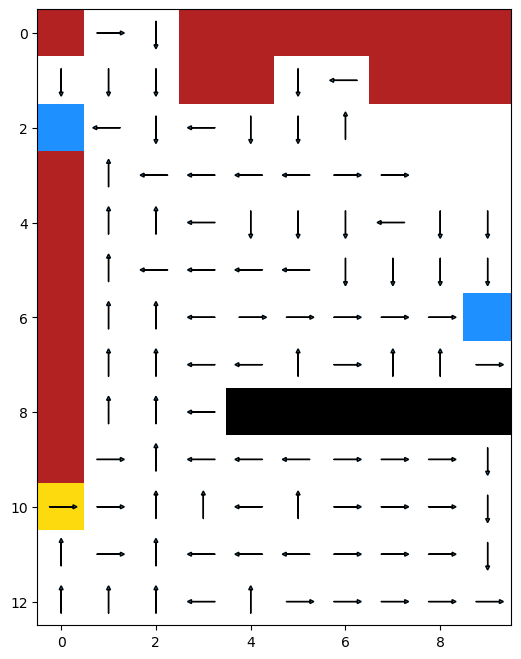

In [1068]:
# Example of running SARSA
agent = SARSA_agent()

s_gamma_3 = 0.95 #Discount
s_alpha_3 = 0.04 #Learning Rate
s_epsilon_3 = 0.03 #Explore Rate
s_tau_3 = 1.2

best_paths = []
best_path, final_path, sarsa_average_rewards_3, s_average_steps_3 = agent.solve(env3, policy="SOFTMAX", gamma=s_gamma_3, alpha=s_alpha_3, epsilon=s_epsilon_3, tau=s_tau_3, n_episodes=no_episodes_3)
best_paths.append(best_path)

for run in range(no_runs_3-1):   
    best_path, final_path, sarsa_rewards_3, sarsa_total_steps_3 = agent.solve(env3, policy='SOFTMAX', gamma=s_gamma_3, alpha=s_alpha_3, epsilon=s_epsilon_3, tau=s_tau_3, n_episodes=no_episodes_3)
    best_paths.append(best_path)
    for i in range(len(s_average_steps_3)):
        s_average_steps_3[i] += sarsa_total_steps_3[i]
        sarsa_average_rewards_3[i] += sarsa_rewards_3[i]
for i in range(len(s_average_steps_3)):
    s_average_steps_3[i] /= no_runs_3
for i in range(len(sarsa_average_rewards_3)):
    sarsa_average_rewards_3[i] /= no_runs_3

for path in best_paths:
    if path[1] > best_path[1]:
        best_path = path
best_path = best_path[0]

loc_best = []
for i in range(len(best_path)):
    loc_best.append(env3.get_loc_from_state(best_path[i]))
loc_final = []
for i in range(len(final_path)):
    loc_final.append(env3.get_loc_from_state(final_path[i]))

print(f"STRATEGY: {loc_best}")
print(f"Best Length: {len(loc_best)}")
print(f"Final Length: {len(loc_final)}")
print(f"TOTAL REWARD: {sarsa_average_rewards_3}")
print(f"TOTAL STEPS: {s_average_steps_3}")

plot_directions(env3, agent)

STRATEGY: [(10, 0), (10, 1), (9, 1), (8, 1), (7, 1), (6, 1), (5, 1), (4, 1), (3, 1), (2, 1), (2, 0)]
Best Length: 11
Final Length: 23
AVERAGE REWARD: [-1.5213098614886862, -1.6522914318539568, -1.459791770894304, -1.6711466151516015, -1.2693676433955208, -1.8562559297490189, -1.3253814806058568, -1.2511771544146728, -1.4697354245390166, -1.0718924837002948, -1.0678798716069577, -1.2866561415788553, -1.0028805098708993, -1.455243870300388, -1.128018477843801, -0.883496606406244, -1.391332902261058, -1.1034396547340832, -0.9193678729204909, -1.2442251156121777, -1.2404065009958039, -0.8823269305349942, -1.0489854420800604, -0.6047966274020823, -1.1230154100075893, -0.8039139875438805, -0.8262865904641105, -0.7956048651188126, -0.8113152675999882, -0.6429540748234974, -0.2580183962147951, -0.45694449046825514, -0.5042666107292045, -0.4843151123428018, -1.0347132873560456, -0.7569734266349458, -0.8384756186216183, -0.7735164052715967, -0.5478792516291502, -0.39245215010469375, -0.358295538

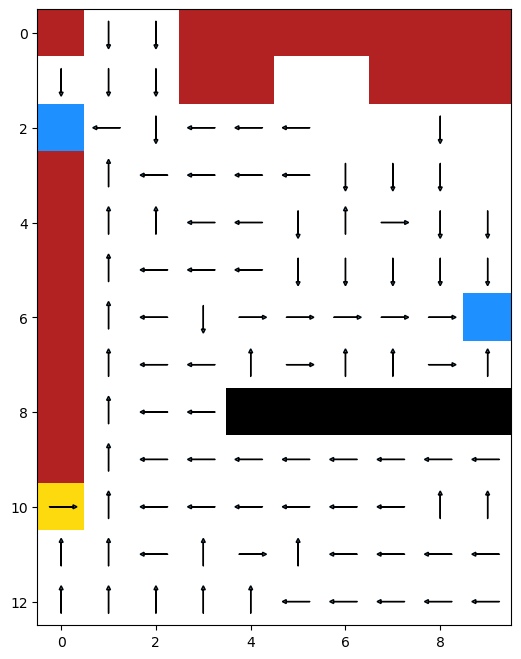

In [1065]:
# Example of running Q-Learning
q_gamma_3 = 0.82 #Discount
q_alpha_3 = 0.08 #Learning Rate
q_epsilon_3 = 0.08 #Explore Rate
q_tau_3 = 1.2

agent = Q_agent()
best_paths = []
best_path, final_path, q_average_rewards_3, q_average_steps_3 = agent.solve(env3, policy='SOFTMAX', gamma=q_gamma_3, alpha=q_alpha_3, epsilon=q_epsilon_3, tau=q_tau_3, n_episodes=no_episodes_3)
best_paths.append(best_path)

for run in range(no_runs_3-1): 
    best_path, final_path, q_rewards_3, q_total_steps_3 = agent.solve(env3, policy='SOFTMAX', gamma=s_gamma_3, alpha=s_alpha_3, epsilon=s_epsilon_3, tau=q_tau_3, n_episodes=no_episodes_3)
    best_paths.append(best_path)
    for i in range(len(q_average_steps_3)):
        q_average_steps_3[i] += q_total_steps_3[i]
        q_average_rewards_3[i] += q_rewards_3[i]
        
for i in range(len(q_average_steps_3)):
    q_average_steps_3[i] /= no_runs_3
for i in range(len(q_average_rewards_3)):
    q_average_rewards_3[i] /= no_runs_3

for path in best_paths:
    if path[1] > best_path[1]:
        best_path = path
best_path = best_path[0]

loc_best = []
for i in range(len(best_path)):
    loc_best.append(env3.get_loc_from_state(best_path[i]))
loc_final = []
for i in range(len(final_path)):
    loc_final.append(env3.get_loc_from_state(final_path[i]))

print(f"STRATEGY: {loc_best}")
print(f"Best Length: {len(loc_best)}")
print(f"Final Length: {len(loc_final)}")
print(f"AVERAGE REWARD: {q_average_rewards_3}")
print(f"AVERAGE STEPS: {q_average_steps_3}")

plot_directions(env3, agent)

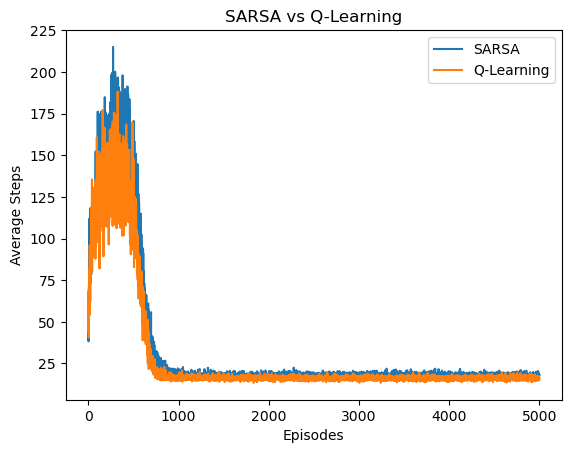

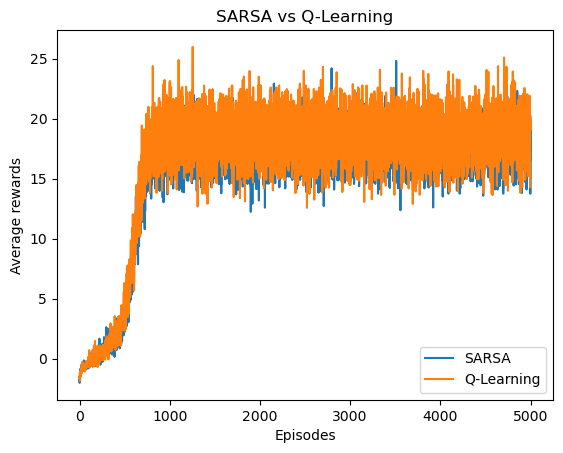

In [1069]:
# Do your plots below! Include any new function definitions in this jupyter notebook!

sarsa_average = np.average(s_average_steps_3)
q_average = np.average(q_average_steps_3)
if sarsa_average > q_average:
    plt.plot(np.mean(np.array(s_average_steps_3).reshape(-1, 1), axis=1), label='SARSA')
    plt.plot(np.mean(np.array(q_average_steps_3).reshape(-1, 1), axis=1), label='Q-Learning')
else:
    plt.plot(np.mean(np.array(q_average_steps_3).reshape(-1, 1), axis=1), label='Q-Learning')
    plt.plot(np.mean(np.array(s_average_steps_3).reshape(-1, 1), axis=1), label='SARSA')
plt.xlabel('Episodes')
plt.ylabel('Average Steps')
plt.legend()
plt.title('SARSA vs Q-Learning')
plt.show()

if sarsa_average > q_average:
    plt.plot(np.mean(np.array(sarsa_average_rewards_3).reshape(-1, 1), axis=1), label='SARSA')
    plt.plot(np.mean(np.array(q_average_rewards_3).reshape(-1, 1), axis=1), label='Q-Learning')
else:
    plt.plot(np.mean(np.array(q_average_rewards_3).reshape(-1, 1), axis=1), label='Q-Learning')
    plt.plot(np.mean(np.array(sarsa_average_rewards_3).reshape(-1, 1), axis=1), label='SARSA')
plt.xlabel('Episodes')
plt.ylabel('Average rewards')
plt.legend()
plt.title('SARSA vs Q-Learning')
plt.show()